<div style="
    border: 3px solid #3498db;
    border-radius: 12px;
    background: linear-gradient(135deg, rgba(52,152,219,0.1), rgba(52,152,219,0.02), white);
    padding: 20px;
    margin: 20px 0;
    font-family: 'Segoe UI', Arial, sans-serif;
    text-align: center;
    box-shadow: 0 4px 12px rgba(0,0,0,0.1);
">
    <br>
    <span style="font-size: 1.6em; font-weight: 600; color: #3498db;">
        Number Identification Model
    </span>
    <div style="margin-top: 12px; font-size: 1.1em; color: #2c3e50;">
        ⚡ CNN | TensorFlow
    </div>
</div>

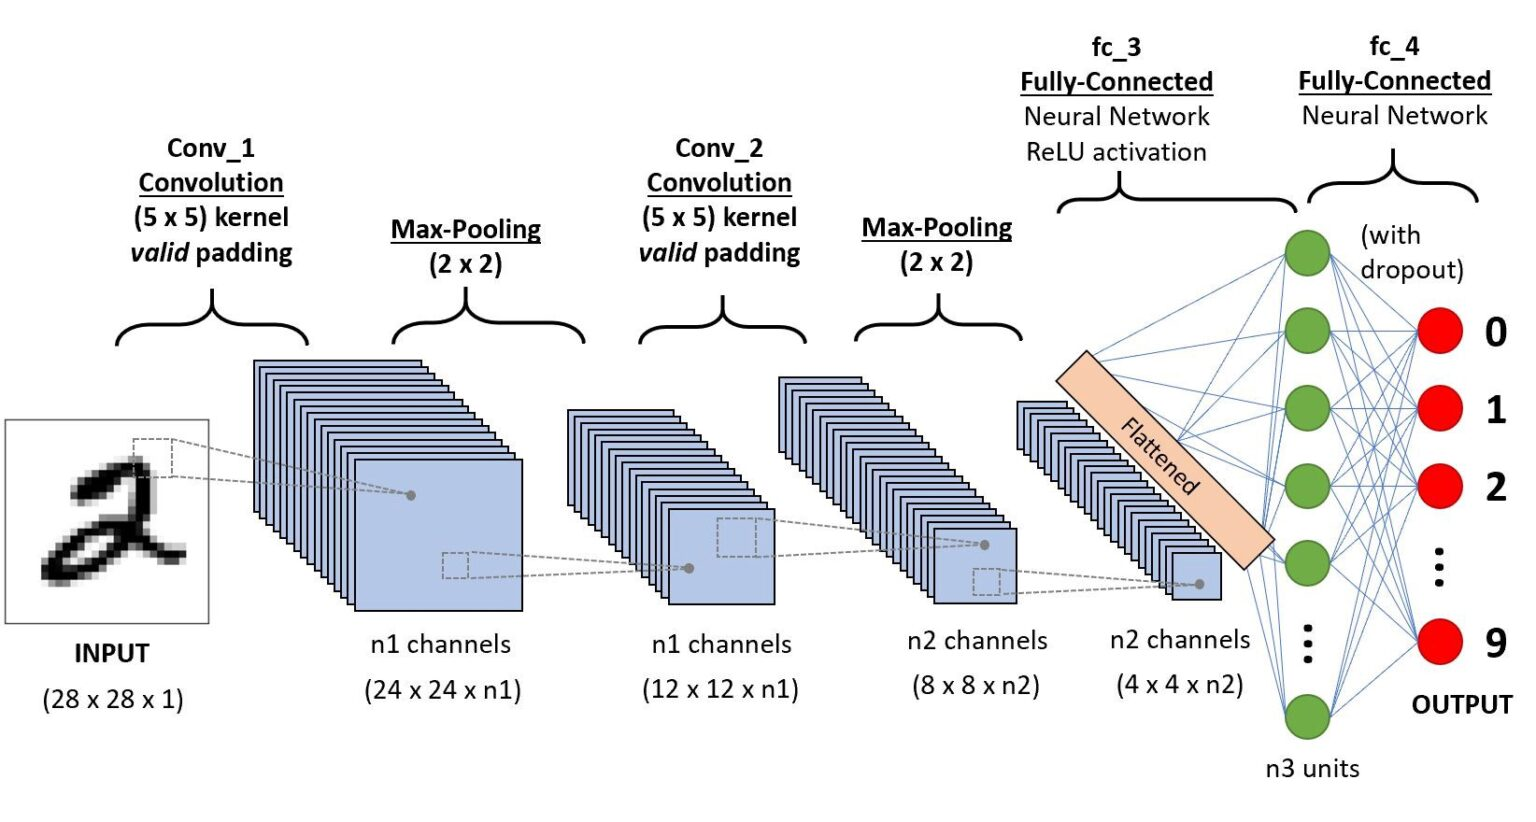

## Step 1: Import Libraries

In [1]:
import numpy as np
import struct
import gzip
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

## Step 2: Prepare the Data

In [2]:
import numpy as np
import zipfile

# Define file paths relative to your notebook location
data_dir = r"C:\Users\Umair Ali\Documents\project\number-identification-model\ubyte-dataset"

# Training data (using the .zip files)
with zipfile.ZipFile(f"{data_dir}\\train-images.idx3-ubyte.zip") as z, z.open("train-images.idx3-ubyte") as f:
    f.read(16)
    x_train = np.frombuffer(f.read(), dtype=np.uint8).reshape(-1, 28, 28)

with open(f"{data_dir}\\train-labels.idx1-ubyte", 'rb') as f:
    f.read(8)
    y_train = np.frombuffer(f.read(), dtype=np.uint8)

# Test data (using the .zip files)
with zipfile.ZipFile(f"{data_dir}\\t10k-images.idx3-ubyte.zip") as z, z.open("t10k-images.idx3-ubyte") as f:
    f.read(16)
    x_test = np.frombuffer(f.read(), dtype=np.uint8).reshape(-1, 28, 28)

with open(f"{data_dir}\\t10k-labels.idx1-ubyte", 'rb') as f:
    f.read(8)
    y_test = np.frombuffer(f.read(), dtype=np.uint8)

In [3]:
print("Original x_train shape:", x_train.shape)
print("Original x_test shape:", x_test.shape)
print("Original y_train shape:", y_train.shape)
print("Original y_test shape:", y_test.shape)

Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)
Original y_train shape: (60000,)
Original y_test shape: (10000,)


In [4]:
# Reshape Images for CNN

# CNN needs image shape like:
# (number_of_images, height, width, channels)
#
# MNIST images are grayscale, so channel = 1
#-1 in reshape means: “auto-calculate this dimension.”

x_train = x_train.reshape(-1, 28, 28, 1)      #Here -1 automatically becomes 60000.
x_test = x_test.reshape(-1, 28, 28, 1)        # Here -1 automatically becomes 10000. no need manually writing

In [5]:
# Convert Images to Float

# Pixel values are integers like 0, 1, 2, ..., 255
# We convert them to float values for neural network training

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

In [6]:
# Normalize Pixel Values

# Original pixel range: 0 to 255
# After dividing by 255: 0 to 1
#
# This helps the model train faster and better

x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# Check New Image Shape

print("Processed x_train shape:", x_train.shape)
print("Processed x_test shape:", x_test.shape)

Processed x_train shape: (60000, 28, 28, 1)
Processed x_test shape: (10000, 28, 28, 1)


In [8]:
# One-Hot Encode Labels

# Original label example:
# 5
#
# One-hot encoded label:
# [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
#
# Because MNIST has 10 classes: 0 to 9

y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [9]:
print("One-hot encoded y_train shape:", y_train.shape)
print("One-hot encoded y_test shape:", y_test.shape)

One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)


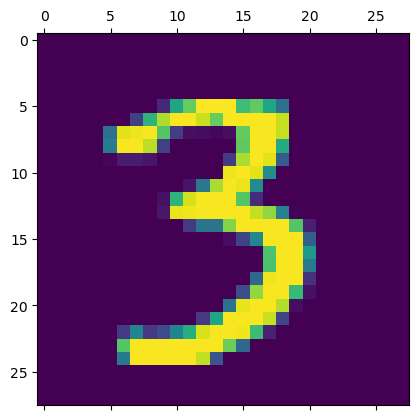

In [10]:
import matplotlib.pyplot as plt
plt.matshow(x_train[10000])

## Step 3: Build the Model


### CNN Model Explanation

This CNN model is used for **MNIST digit classification**.
It takes a **28×28 grayscale image** and predicts one digit from **0 to 9**.

---

### Model Layers

### 1. `Sequential`

Sequential means we are building the model layer by layer.
Each layer passes its output to the next layer.Input Image → Conv → Pool → Conv → Pool → Conv → Pool → Flatten → Dense → Output

### 2. `Conv2D`

Convolution layers extract image features such as edges, lines, curves, and digit patterns.

```python
Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1))
```

* `32`, `64`, `128` = number of filters means means the model will learn 32,64,128 different features.The first convolution layer learns simple features like edges and lines.The second convolution layer learns more advanced patterns, such as parts of digits.As the model goes deeper, it learns more complex features.The third convolution layer can learn stronger digit-related patterns
* `(3, 3)` = filter size means each filter looks at a 3 × 3 pixel area at a time.
* `relu` = helps the model learn non-linear patterns
* `input_shape=(28, 28, 1)` = 28×28 grayscale image

As the model goes deeper, it learns more complex features.

### 3. `MaxPooling2D`

Pooling reduces the feature map size and keeps the most important features.

```python
MaxPooling2D(pool_size=(2, 2))
```

It helps reduce computation and overfitting.

### 4. `Flatten`

`Flatten()` converts the 2D feature maps into a 1D vector so it can be passed into Dense layers.

### 5. `Dense`

Dense layers are fully connected layers.
They use the extracted features to classify the digit.

```python
Dense(128, activation='relu')
```

### 6. `Dropout`

Dropout reduces overfitting.

```python
Dropout(0.5)
```

It randomly turns off 50% of neurons during training, so the model learns more general patterns.

### 7. Output Layer

```python
Dense(10, activation='softmax')
```

The output layer has **10 neurons** because MNIST has 10 classes: 0 to 9.
`softmax` gives the probability for each digit.
Example output:

[0.01, 0.02, 0.01, 0.03, 0.01, 0.85, 0.02, 0.01, 0.03, 0.01]

The highest probability is 0.85 at position 5.

So, the model predicts:

Digit = 5

---

### Overall Flow

```text
Image → Conv2D → MaxPooling → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Dropout → Softmax Output
```

---

### Summary

| Layer          | Purpose                                   |
| -------------- | ----------------------------------------- |
| `Conv2D`       | Extracts image features                   |
| `MaxPooling2D` | Reduces size and keeps important features |
| `Flatten`      | Converts features into 1D                 |
| `Dense`        | Performs classification                   |
| `Dropout`      | Reduces overfitting                       |
| `Softmax`      | Gives final class probabilities           |



In [11]:
model = Sequential([
    
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(10, activation='softmax')
])

C:\Users\Umair Ali\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Compile the Model

Compile the model with an optimizer, loss function, and metrics:

We use `model.compile()` to prepare the model for training.Before training, TensorFlow needs to know three important things:

1. **Optimizer**
   The optimizer decides how the model updates its weights during training.

2. **Loss Function**
   The loss function measures how wrong the model prediction is.

3. **Metric**
   The metric is used to check the model performance during training and evaluation.

```python
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
```

In this model:

* `Adam()` helps the model learn by updating weights.
* `categorical_crossentropy` is used because the labels are one-hot encoded.
* `accuracy` shows how many predictions are correct.


In [13]:
model.compile(
                optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy']
            )

## Step 5: Train the Model

``` Train the model using the training data: ```

In [14]:
history=model.fit(x_train,                   #training images
          y_train,                   #training labels
          epochs=1,                 # the model will see the full training data 1 time 
          batch_size=128,            # the model updates weights after seeing 128 images at a time
          validation_split=0.2)      # 20% of the training data is used for validation

375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 161ms/step - accuracy: 0.8626 - loss: 0.4455 - val_accuracy: 0.9669 - val_loss: 0.1091


## Step 6: Evaluate the Model

``` Evaluate the model using the test data to check its performance: ```

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9700 - loss: 0.1013
Test Loss: 0.10133559256792068
Test Accuracy: 0.9700000286102295


``` Training accuracy high + validation accuracy low = overfitting ``` <br>
``` Both accuracy low = underfitting ```<br>
``` Both accuracy high = good model ```

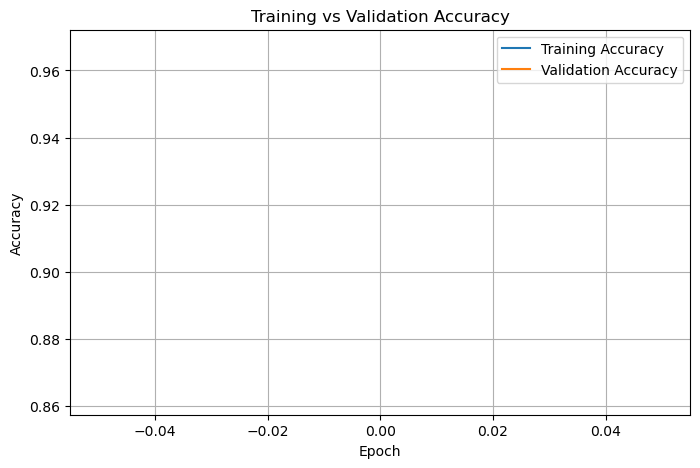

In [16]:
import matplotlib.pyplot as plt

# =========================================================
# STEP: Plot Training and Validation Accuracy
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

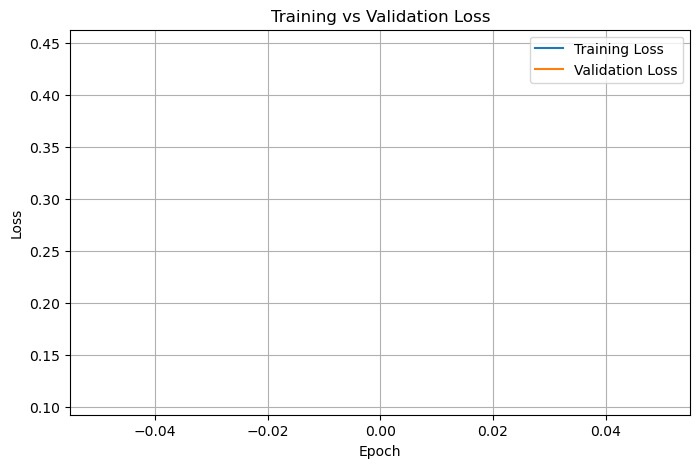

In [17]:
# =========================================================
# STEP: Plot Training and Validation Loss
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The CNN model performed very well, with training and validation accuracy reaching around **98–99%**. Both losses decreased steadily, showing that prediction error reduced over time.

Since the training and validation curves are close, there is no major overfitting.This means the model performs well not only on training data but also on unseen validation data. Overall, the model is accurate and stable for MNIST digit classification.


## Step 7 : Make Predictions

In [18]:
# =========================================================
# STEP: Make Predictions
# =========================================================

y_pred_prob = model.predict(x_test)

# Convert probabilities to class labels
y_pred = y_pred_prob.argmax(axis=1)

# Convert one-hot encoded y_test back to class labels
y_true = y_test.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


In [19]:
print("Actual label:", y_true[6])
print("Predicted label:", y_pred[6])

Actual label: 4
Predicted label: 4


#### Show Image with Prediction

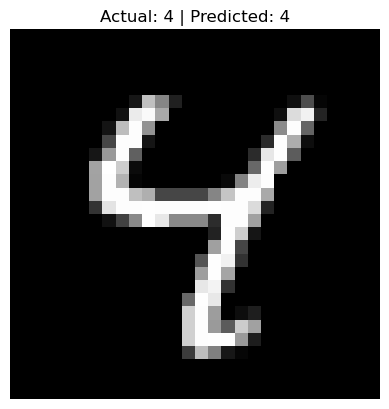

In [20]:
index = 6

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Actual: {y_true[index]} | Predicted: {y_pred[index]}")
plt.axis('off')
plt.show()

## Step 8: Confusion Matrix

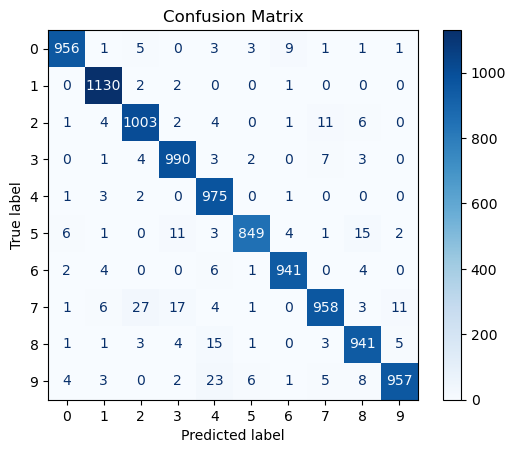

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# STEP: Confusion Matrix
# =========================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()